# AWBS - Project 1
author: Mateusz Domalewski

group: 2

index: 288761

In [1]:
DATA_2023 = "./data_202302/"
DATA_2021 = "./data_202102/"

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from datetime import datetime

## Business understanding

### Determining objectives

- Analysis of Internet traffic performance
- Account the download and upload packages
- Incorporate establishing relationships (influences) between parameters refering to Internet traffic performance

### Data mining goals

- Compare Internet traffic performance of dataset from 2023 with the data from 2021
- Clearly present tasks and results. Use tables, charts, diagrams.
- Provide comparative analysis for different prediction algorithms.
- Provide conclusions

### Project Plan

- perform a prediction of a selected parameter related to the performance of Internet traffic
- propose three different, appropriate models for prediction, present their synthetic characteristics, justification for use, limitations, selected set of parameters and their values.


## Data understanding

### Collecting initial data

|dataset|year|link|
|---|---|---|
|data_raw_2023_02| 2023 | https://data.fcc.gov/download/measuring-broadband-america/2023/data-raw-2023-feb.tar.gz |
| data_raw_2021_02 | 2021 | https://data.fcc.gov/download/measuring-broadband-america/2021/data-raw-2021-feb.tar.gz |

### Describing data

#### 2023 upload and dowload

In [2]:
import polars as pl

upload_2023 = pl.read_csv(DATA_2023+"curr_lct_ul.csv")
download_2023 = pl.read_csv(DATA_2023+"curr_lct_dl.csv")

##### **upload 2023**

In [3]:
upload_2023.describe()

statistic,unit_id,ddate,dtime,target,address,packets_received,packets_sent,packet_size,bytes_total,duration,bytes_sec,error_code,successes,failures
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64
"""count""",869043.0,"""869043""","""869043""","""869043""","""869043""",869043.0,869043.0,869043.0,869043.0,869043.0,869043.0,"""869043""",869043.0,869043.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0
"""mean""",2.2472e7,null,null,null,null,91.470139,99.272878,1400.0,128058.194589,308216.803378,6.1957e6,null,0.992729,0.007271
"""std""",2.5433e7,null,null,null,null,20.589431,8.49609,0.0,28825.203781,474150.203915,1.4260e7,null,0.084961,0.084961
"""min""",386.0,"""2023-01-31""","""2023-02-01 00:00:03""","""sk-1.uhnet.net""","""0.0.0.0""",0.0,0.0,1400.0,0.0,0.0,0.0,"""EXPORT_ERROR""",0.0,0.0
"""25%""",805922.0,null,null,null,null,100.0,100.0,1400.0,140000.0,19884.0,224069.0,null,1.0,0.0
"""50%""",4.172709e6,null,null,null,null,100.0,100.0,1400.0,140000.0,62963.0,1.95209e6,null,1.0,0.0
"""75%""",3.9486057e7,null,null,null,null,100.0,100.0,1400.0,140000.0,442474.0,6.599104e6,null,1.0,0.0
"""max""",9.3007349e7,"""2023-02-28""","""2023-02-28 23:59:56""","""sp2-vm-newyork-us.samknows.com""","""74.40.74.101""",100.0,100.0,1400.0,140000.0,9.254213e6,7.13207547e8,"""ZERO_RECEIVED_SERVER""",1.0,1.0


In [4]:
upload_hist = upload_2023.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h"))
upload_hist = upload_hist.group_by(["dtime"]).agg(pl.col("packets_sent").sum(), (pl.col("bytes_sec").mean() / 1_000_000).alias("mbytes_sec"), pl.col(["successes", "failures"]).mean() * 100.0).sort(["dtime"])
upload_hist

dtime,packets_sent,mbytes_sec,successes,failures
datetime[μs],i64,f64,f64,f64
2023-02-01 00:00:00,133000,6.06244,98.884758,1.115242
2023-02-01 01:00:00,279800,5.872537,99.149539,0.850461
2023-02-01 02:00:00,306900,6.212253,99.191984,0.808016
2023-02-01 03:00:00,328700,5.894447,99.215213,0.784787
2023-02-01 04:00:00,337200,5.972213,99.264057,0.735943
…,…,…,…,…
2023-02-28 20:00:00,55800,6.148567,99.642857,0.357143
2023-02-28 21:00:00,55300,6.68533,99.281867,0.718133
2023-02-28 22:00:00,58100,6.347422,98.809524,1.190476


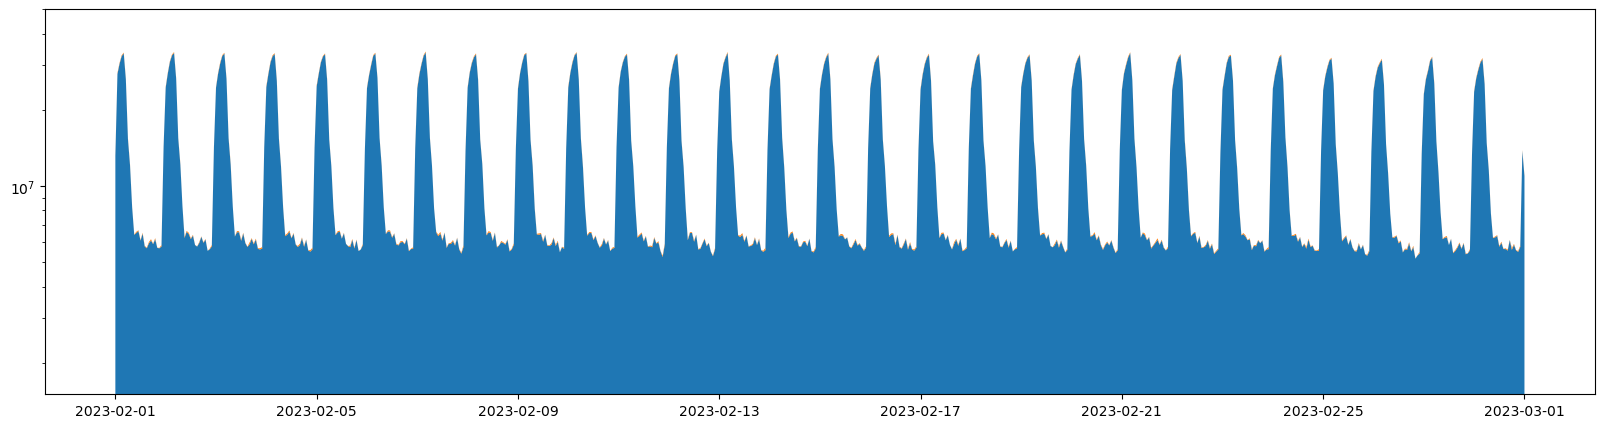

In [5]:
times, packets, mbytes_sec, successes, failures = upload_hist.cast({"dtime" : pl.String}).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(figsize=[20,5])

stacked = np.array([successes, failures]) * packets

ax.set_ylim(1.5 * 10 ** 6, 5 * 10 ** 7)

ax.set_yscale("log")

ax.stackplot(times, stacked.astype(int))

plt.show()

##### **Download 2023**

In [6]:
download_2023.describe()

statistic,unit_id,ddate,dtime,target,address,packets_received,packets_sent,packet_size,bytes_total,duration,bytes_sec,error_code,successes,failures
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64
"""count""",869701.0,"""869701""","""869701""","""869701""","""869701""",869701.0,869701.0,869701.0,869701.0,869701.0,869701.0,"""869701""",869701.0,869701.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0
"""mean""",2.2410e7,null,null,null,null,86.66543,99.667242,1400.0,121331.60178,33574.694549,3.1210e7,null,0.996672,0.003328
"""std""",2.5417e7,null,null,null,null,20.926162,5.758916,0.0,29296.626978,107545.596092,3.5901e7,null,0.057589,0.057589
"""min""",386.0,"""2023-01-31""","""2023-02-01 00:00:00""","""sk-1.uhnet.net""","""0.0.0.0""",0.0,0.0,1400.0,0.0,0.0,0.0,"""NO_ERROR""",0.0,0.0
"""25%""",805804.0,null,null,null,null,77.0,100.0,1400.0,107800.0,5606.0,4.770858e6,null,1.0,0.0
"""50%""",4.172669e6,null,null,null,null,100.0,100.0,1400.0,140000.0,9491.0,1.371387e7,null,1.0,0.0
"""75%""",3.9486017e7,null,null,null,null,100.0,100.0,1400.0,140000.0,23817.0,4.5768056e7,null,1.0,0.0
"""max""",9.3007349e7,"""2023-02-28""","""2023-02-28 23:59:59""","""sp2-vm-newyork-us.samknows.com""","""96.99.224.233""",100.0,100.0,1400.0,140000.0,3.004544e6,3.248e8,"""ZERO_SENT_SERVER""",1.0,1.0


In [7]:
dwload_hist = download_2023.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h"))
dwload_hist = dwload_hist.group_by(["dtime"]).agg(pl.col("packets_sent").sum(), (pl.col("bytes_sec").mean() / 1_000_000).alias("mbytes_sec"), pl.col(["successes", "failures"]).mean() * 100.0).sort(["dtime"])
dwload_hist

dtime,packets_sent,mbytes_sec,successes,failures
datetime[μs],i64,f64,f64,f64
2023-02-01 00:00:00,135300,31.365133,99.558499,0.441501
2023-02-01 01:00:00,280500,30.806859,99.53868,0.46132
2023-02-01 02:00:00,308300,30.913645,99.580103,0.419897
2023-02-01 03:00:00,334700,29.908655,99.494649,0.505351
2023-02-01 04:00:00,341800,30.773184,99.708285,0.291715
…,…,…,…,…
2023-02-28 20:00:00,56400,30.877067,99.646643,0.353357
2023-02-28 21:00:00,55700,32.925269,99.464286,0.535714
2023-02-28 22:00:00,58100,29.009264,99.486301,0.513699


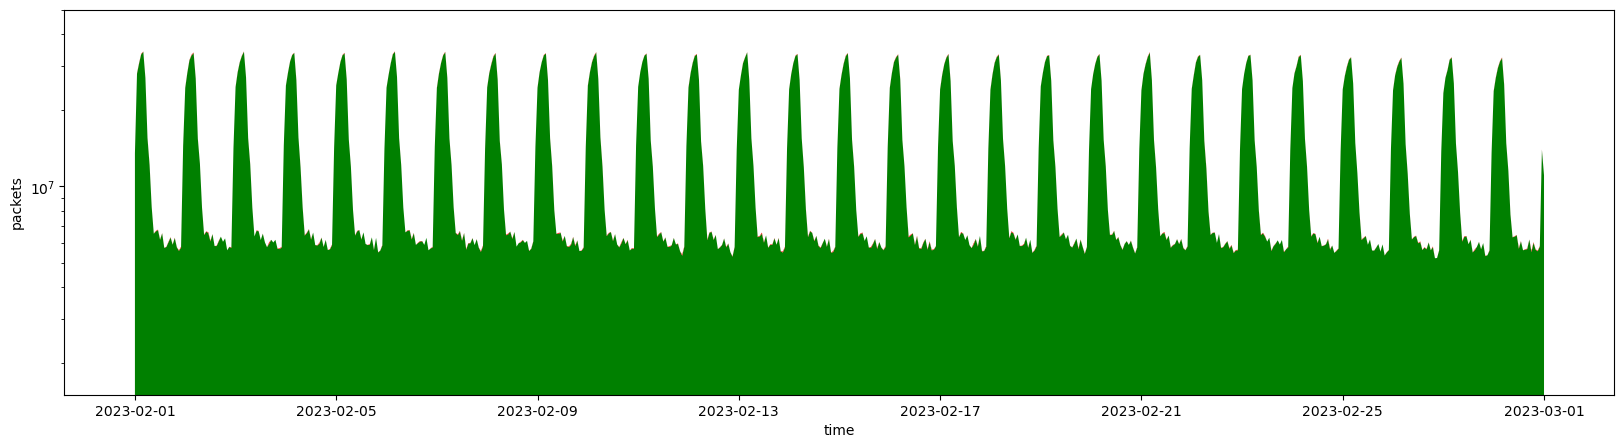

In [8]:
times, packets, mbytes_sec, successes, failures = dwload_hist.cast({"dtime" : pl.String}).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(figsize=[20,5])

stacked = np.array([successes, failures]) * packets

ax.set_xlabel("time")

ax.set_ylabel("packets")

ax.set_ylim(1.5 * 10 ** 6, 5 * 10 ** 7)

ax.set_yscale("log")

ax.stackplot(times, stacked.astype(int), colors=["green", "red"])

plt.show()

#### Possibly interesting datasets from 2023

##### **Upload ping**

In [9]:
ul_ping = pl.read_csv(DATA_2023+"curr_ulping.csv")

In [10]:
ul_ping.describe()

statistic,unit_id,dtime,target,rtt_avg,rtt_min,rtt_max,rtt_std,successes,failures
str,f64,str,str,f64,f64,f64,f64,f64,f64
"""count""",1.260944e6,"""1260944""","""1260944""",1.260944e6,1.260944e6,1.260944e6,1.260944e6,1.260944e6,1.260944e6
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.3270e7,null,null,246504.206554,25685.968431,368149.587011,69536.47149,131.431135,8.57364
"""std""",2.5577e7,null,null,436911.773699,52241.127707,592335.0741,149473.353031,202.881023,26.916415
"""min""",386.0,"""2023-02-01 00:00:00""","""01-on-regional-albuquerque.sam…",0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",806008.0,null,null,28088.0,9871.0,53384.0,5252.0,116.0,0.0
"""50%""",2.4525377e7,null,null,59956.0,16179.0,143171.0,19143.0,143.0,0.0
"""75%""",3.9486401e7,null,null,244234.0,28518.0,364661.0,54473.0,151.0,4.0
"""max""",9.3007349e7,"""2023-02-28 23:59:59""","""whplny-1-on.cv.net""",2.995536e6,2.995536e6,2.999999e6,1.518446e6,159510.0,1378.0


In [11]:
ulp_data = ul_ping.group_by("target").agg(pl.col("target").unique_counts().alias("data_amount"))
common_targets = upload_2023.select("target").unique().join(ulp_data, how="left", on="target")
common_targets

target,data_amount
str,list[u32]
"""sp1-vm-losangeles-us.samknows.…",[64950]
"""sp1-vm-dallas-us.samknows.com""",[50233]
"""sp1-vm-chicago-us.samknows.com""",[91995]
"""sk-1.uhnet.net""",[6266]
"""sp2-vm-newyork-us.samknows.com""",[54870]
…,…
"""sp1-vm-newyork-us.samknows.com""",[45741]
"""sp1-vm-denver-us.samknows.com""",[38760]
"""sp1-vm-seattle-us.samknows.com""",[54804]


##### **Download ping**

In [12]:
dl_ping = pl.read_csv(DATA_2023+"curr_dlping.csv")

In [13]:
dl_ping.describe()

statistic,unit_id,dtime,target,rtt_avg,rtt_min,rtt_max,rtt_std,successes,failures
str,f64,str,str,f64,f64,f64,f64,f64,f64
"""count""",1.246832e6,"""1246832""","""1246832""",1.246832e6,1.246832e6,1.246832e6,1.246832e6,1.246832e6,1.246832e6
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.3139e7,null,null,105448.482533,23554.363431,190590.062653,41161.446109,149.791145,5.984578
"""std""",2.5552e7,null,null,199475.926837,41634.751442,372684.883975,97133.519491,656.420056,236.331869
"""min""",386.0,"""2023-02-01 00:00:00""","""01-on-regional-albuquerque.sam…",0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",805700.0,null,null,21505.0,8566.0,33583.0,3573.0,123.0,0.0
"""50%""",2.4328809e7,null,null,42594.0,14618.0,69319.0,8641.0,141.0,0.0
"""75%""",3.9486317e7,null,null,95253.0,27280.0,162710.0,28391.0,164.0,2.0
"""max""",9.3007349e7,"""2023-02-28 23:59:58""","""whplny-1-on.cv.net""",2.846991e6,2.71029e6,2.999992e6,1.548048e6,430309.0,140604.0


In [14]:
dlp_data = dl_ping.group_by("target").agg(pl.col("target").unique_counts().alias("data_amount"))
common_targets = download_2023.select("target").unique().join(dlp_data, how="left", on="target")
common_targets

target,data_amount
str,list[u32]
"""sp1-vm-losangeles-us.samknows.…",[64396]
"""sp1-vm-atlanta-us.samknows.com""",[68792]
"""sp2-vm-chicago-us.samknows.com""",[85470]
"""sp1-vm-miami-us.samknows.com""",[29430]
"""sp1-vm-denver-us.samknows.com""",[38338]
…,…
"""sp1-vm-dallas-us.samknows.com""",[49854]
"""sp1-vm-newyork-us.samknows.com""",[45355]
"""sp1-vm-chicago-us.samknows.com""",[90972]


## Data preparation

### Upload averages

In [15]:
up_avgs = upload_2023.group_by(["target"], maintain_order=True).agg(pl.col("packets_sent").mean().name.suffix("_mean"), pl.col("packets_sent").std().name.suffix("_stdev"), (pl.col("successes").mean() * 100).name.suffix("_pct"), (pl.col("failures").mean() * 100).name.suffix("_pct") )

up_avgs = up_avgs.sort("target").fill_null(0.0)

up_avgs

target,packets_sent_mean,packets_sent_stdev,successes_pct,failures_pct
str,f64,f64,f64,f64
"""sk-1.uhnet.net""",99.183511,8.999462,99.183511,0.816489
"""sp1-vm-ashburn-us.samknows.com""",99.187515,8.977155,99.187515,0.812485
"""sp1-vm-atlanta-us.samknows.com""",99.509582,6.98583,99.509582,0.490418
"""sp1-vm-chicago-us.samknows.com""",99.143512,9.214987,99.143512,0.856488
"""sp1-vm-dallas-us.samknows.com""",99.18698,8.980102,99.18698,0.81302
…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",98.990189,9.998188,98.990189,1.009811
"""sp1-vm-seattle-us.samknows.com""",99.565673,6.576074,99.565673,0.434327
"""sp2-vm-ashburn-us.samknows.com""",92.857143,26.226526,92.857143,7.142857


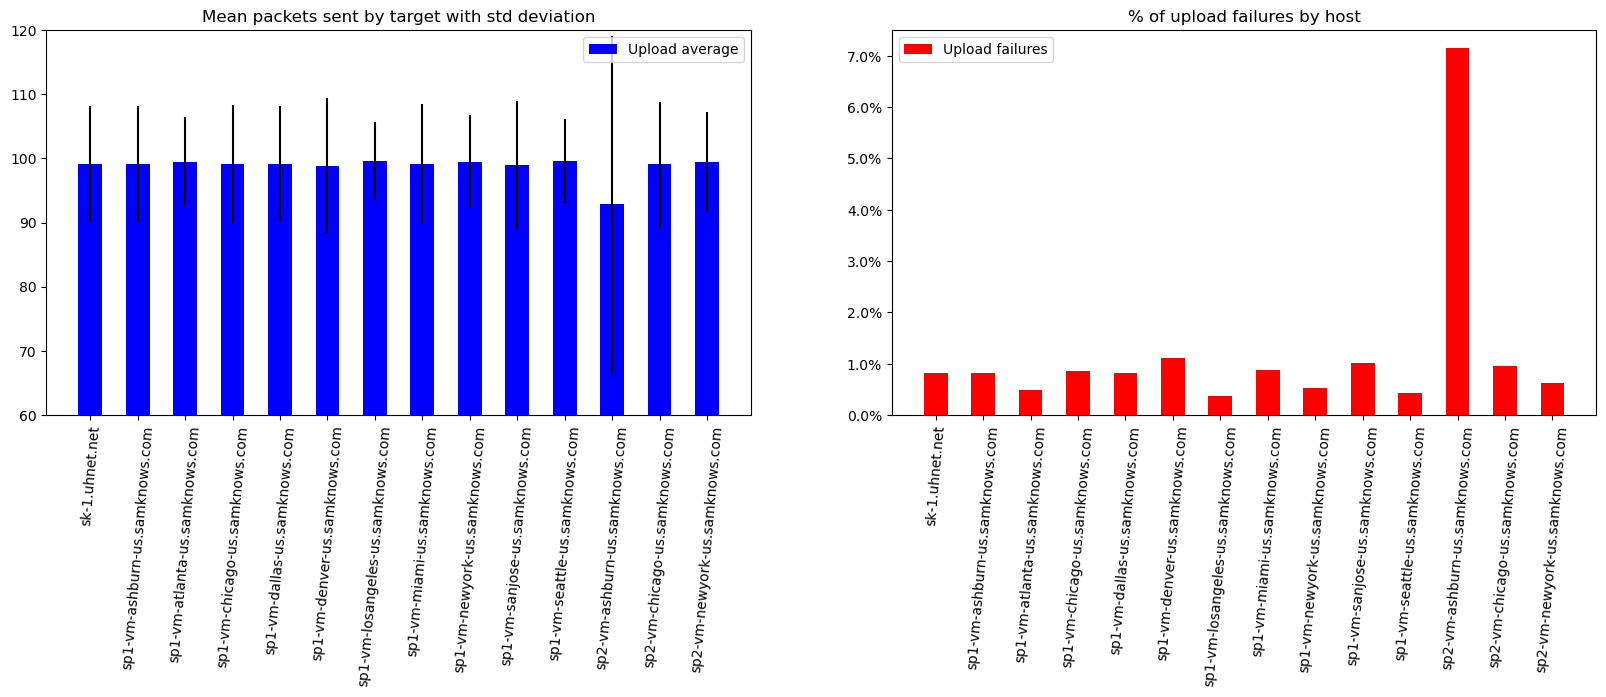

In [16]:
targets, up_means, up_stdev, up_oks, up_fails = up_avgs.to_numpy().transpose()


fig, ax = plt.subplots(1, 2, figsize=[20,5])

# means
ax[0].bar(targets, up_means, width=0.5, yerr=up_stdev, label="Upload average", color="blue")
ax[0].set_ylim(60.0, 120.0)
ax[0].set_title("Mean packets sent by target with std deviation")

# failures

ax[1].bar(targets, up_fails, width=0.5, label="Upload failures", color="red")
ax[1].yaxis.set_major_formatter(ticker.PercentFormatter())
ax[1].set_title("% of upload failures by host")

for i in range(len(ax)):
    ax[i].legend()
    ax[i].autoscale_view()
    ax[i].tick_params(axis="x", rotation=85)

plt.show()

### Upload errors

In [17]:
errors = upload_2023.group_by(["target", "error_code"]).agg(pl.col("error_code").count().alias("amount"))

errors = errors.join(upload_2023.group_by("target").agg(pl.col("failures").sum().alias("total")), how="left", on="target")

errors = errors.with_columns(amount_pct = pl.col("amount") * 100 / pl.col("total"))

errors = errors.pivot(on="error_code", index="target", values="amount_pct").drop("NO_ERROR").fill_null(0.0).sort("target")

errors

target,ZERO_RECEIVED_SERVER,RCV_FAILED,JSON_PARSE_ERROR,EXPORT_ERROR,TCP_CONNECT,SEND_FAILED,TCP_RECV
str,f64,f64,f64,f64,f64,f64,f64
"""sk-1.uhnet.net""",15.853659,29.268293,2.439024,0.0,52.439024,0.0,0.0
"""sp1-vm-ashburn-us.samknows.com""",1.091405,6.548431,2.18281,0.0,82.946794,7.230559,0.0
"""sp1-vm-atlanta-us.samknows.com""",2.941176,10.714286,3.781513,0.210084,68.907563,13.445378,0.0
"""sp1-vm-chicago-us.samknows.com""",1.927195,3.640257,2.35546,0.0,71.627409,20.449679,0.0
"""sp1-vm-dallas-us.samknows.com""",2.752294,10.642202,15.779817,0.0,69.174312,1.651376,0.0
…,…,…,…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",3.791469,8.056872,53.317536,0.0,28.672986,6.161137,0.0
"""sp1-vm-seattle-us.samknows.com""",6.382979,9.219858,8.865248,0.0,75.531915,0.0,0.0
"""sp2-vm-ashburn-us.samknows.com""",50.0,50.0,0.0,0.0,0.0,0.0,0.0


14


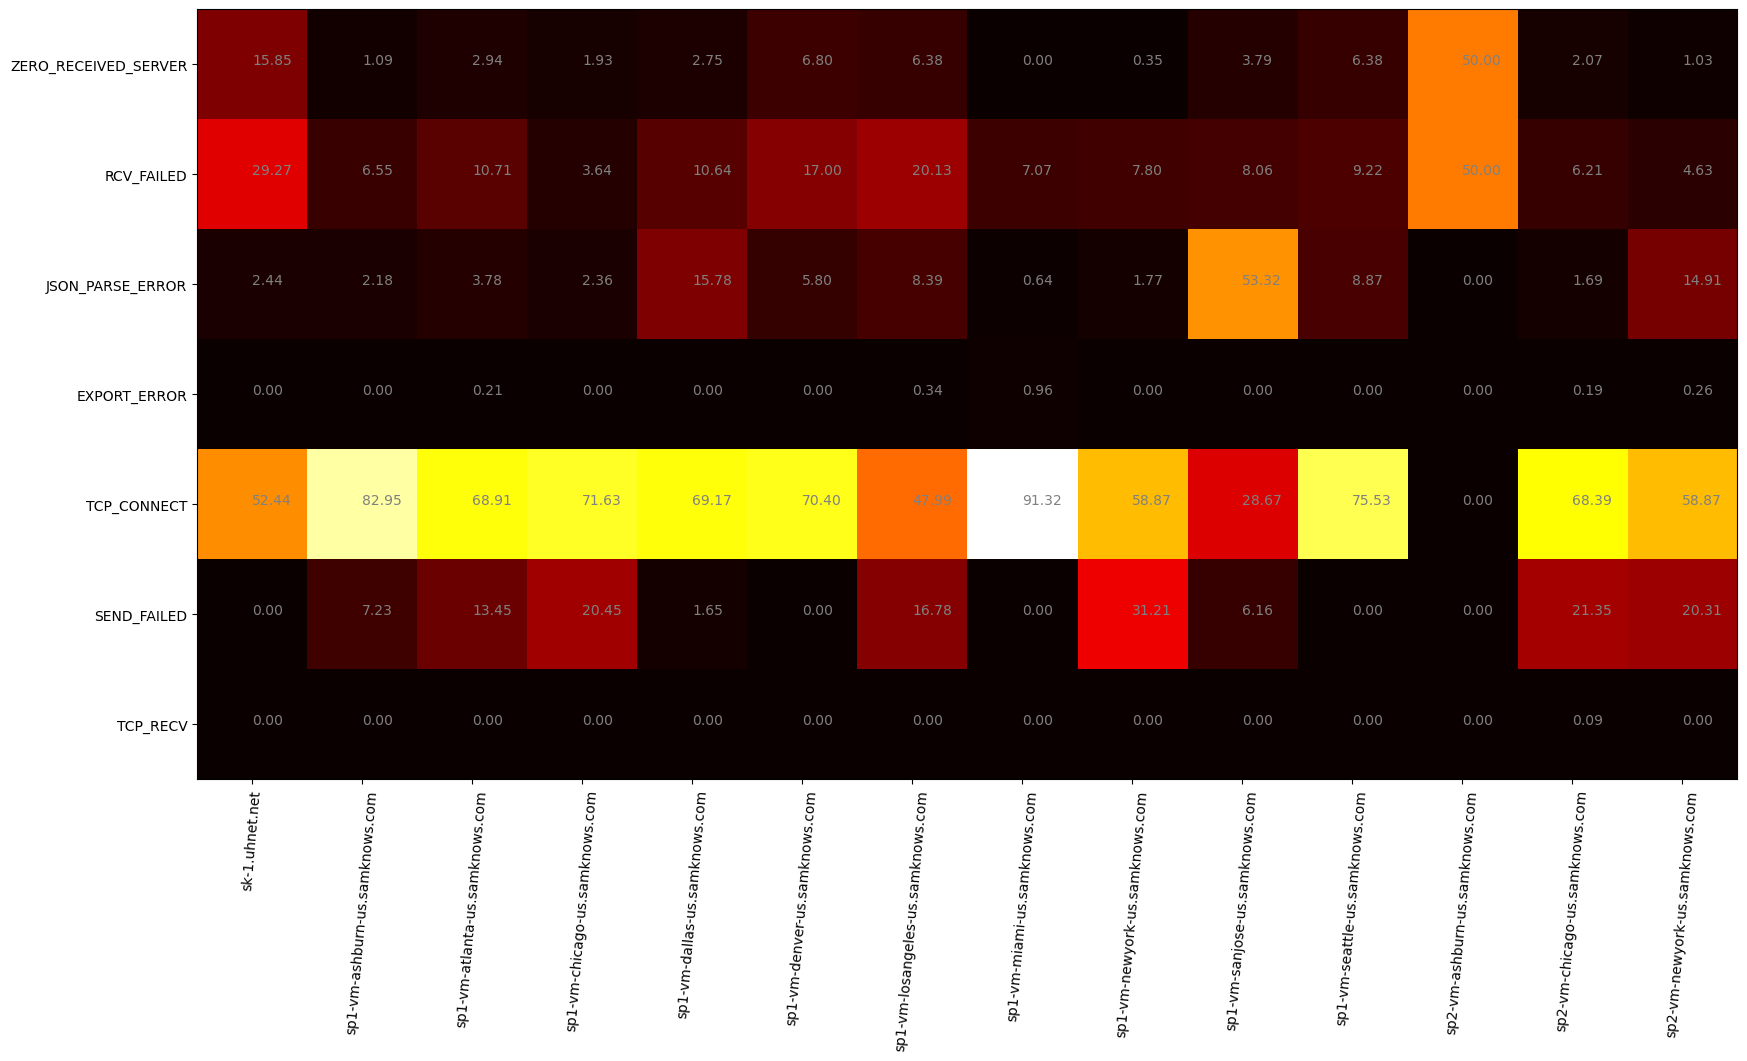

In [18]:
err_types = errors.columns[1:]

targets = errors.to_numpy().transpose()
values = targets[1:].astype(float)
targets = targets[0]

print(len(targets))

fig, ax = plt.subplots(figsize = [25, 10])
ax.imshow(values, cmap="hot")
ax.set_xticks(range(len(targets)), labels=targets, rotation=85)
ax.set_yticks(range(len(err_types)), labels=err_types)

for x in range(len(targets)):
    for y in range(len(err_types)):
        ax.text(x, y, f"{values[y][x]:.2f}", color="gray")

plt.show()

### Download averages

In [19]:
dw_avgs = download_2023.group_by(["target"], maintain_order=True).agg(pl.col("packets_received").mean().name.suffix("_mean"), pl.col("packets_received").std().name.suffix("_stdev"), (pl.col("successes").mean() * 100).name.suffix("_pct"), (pl.col("failures").mean() * 100).name.suffix("_pct") )

dw_avgs = dw_avgs.sort("target").fill_null(0.0)

dw_avgs

target,packets_received_mean,packets_received_stdev,successes_pct,failures_pct
str,f64,f64,f64,f64
"""sk-1.uhnet.net""",91.126478,16.719704,99.513164,0.486836
"""sp1-vm-ashburn-us.samknows.com""",89.157478,18.943243,99.701347,0.298653
"""sp1-vm-atlanta-us.samknows.com""",87.476392,19.428849,99.663918,0.336082
"""sp1-vm-chicago-us.samknows.com""",84.214081,22.357806,99.675108,0.324892
"""sp1-vm-dallas-us.samknows.com""",88.259337,19.594169,99.710772,0.289228
…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",90.522035,18.668834,99.103771,0.896229
"""sp1-vm-seattle-us.samknows.com""",83.70247,23.118496,99.685675,0.314325
"""sp2-vm-ashburn-us.samknows.com""",85.392857,21.615048,100.0,0.0


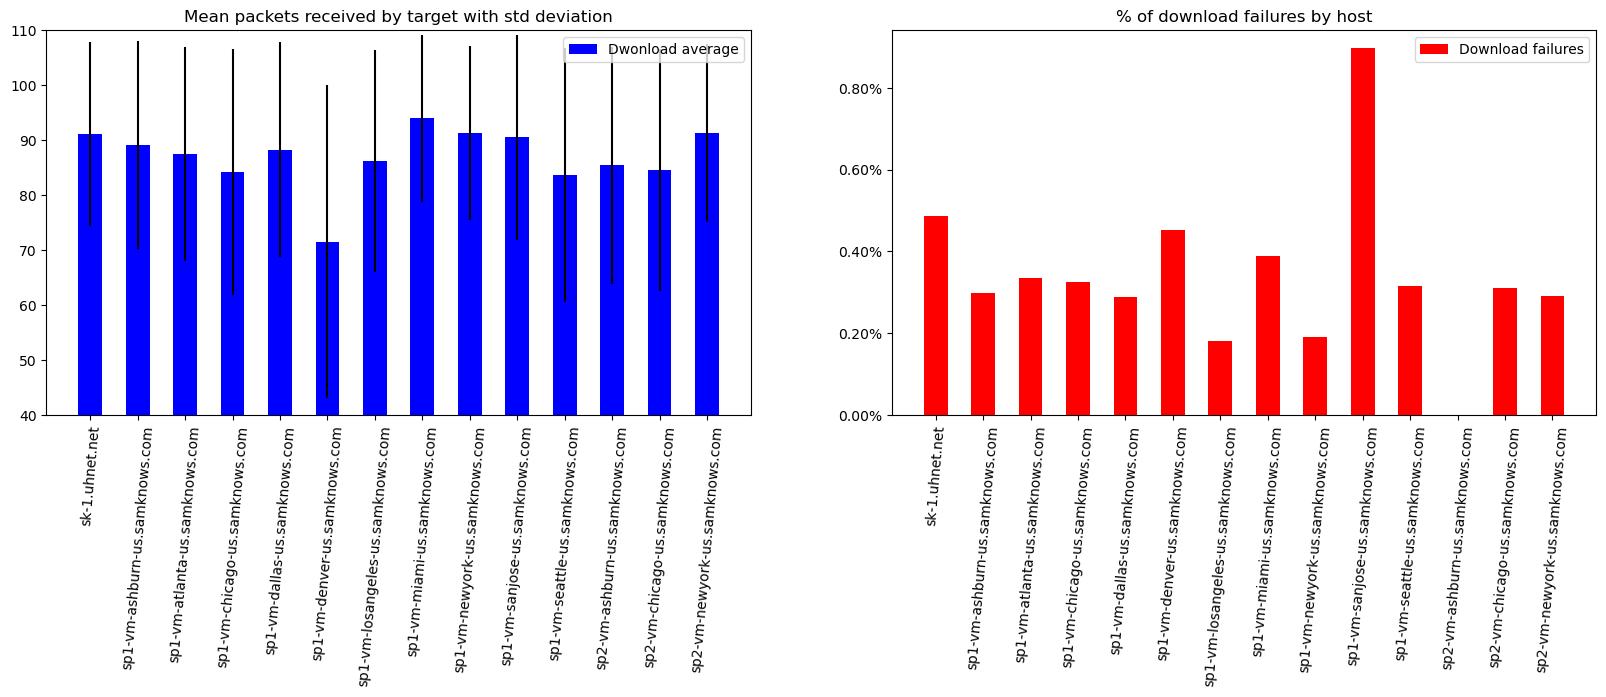

In [20]:
targets, dw_means, dw_stdev, dw_oks, dw_fails = dw_avgs.to_numpy().transpose()


fig, ax = plt.subplots(1, 2, figsize=[20,5])

# means
ax[0].bar(targets, dw_means, width=0.5, yerr=dw_stdev, label="Dwonload average", color="blue")
ax[0].set_ylim(40.0, 110.0)
ax[0].set_title("Mean packets received by target with std deviation")

# failures

ax[1].bar(targets, dw_fails, width=0.5, label="Download failures", color="red")
ax[1].yaxis.set_major_formatter(ticker.PercentFormatter())
ax[1].set_title("% of download failures by host")

for i in range(len(ax)):
    ax[i].legend()
    ax[i].autoscale_view()
    ax[i].tick_params(axis="x", rotation=85)

plt.show()

### Download errors

In [21]:
errors = download_2023.group_by(["target", "error_code"]).agg(pl.col("error_code").count().alias("amount"))

errors = errors.join(upload_2023.group_by("target").agg(pl.col("failures").sum().alias("total")), how="left", on="target")

errors = errors.with_columns(amount_pct = pl.col("amount") * 100 / pl.col("total"))

errors = errors.pivot(on="error_code", index="target", values="amount_pct").drop("NO_ERROR").fill_null(0.0).sort("target")

errors

target,ZERO_SENT_SERVER,TCP_CONNECT,RCV_FAILED,TCP_RECV
str,f64,f64,f64,f64
"""sk-1.uhnet.net""",1.219512,50.0,8.536585,0.0
"""sp1-vm-ashburn-us.samknows.com""",0.545703,34.652115,1.637108,0.0
"""sp1-vm-atlanta-us.samknows.com""",4.621849,59.663866,4.201681,0.0
"""sp1-vm-chicago-us.samknows.com""",1.820128,34.689507,1.498929,0.0
"""sp1-vm-dallas-us.samknows.com""",2.93578,28.807339,3.853211,0.0
…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",51.421801,32.938389,4.50237,0.0
"""sp1-vm-seattle-us.samknows.com""",1.41844,66.312057,4.609929,0.0
"""sp2-vm-ashburn-us.samknows.com""",0.0,0.0,0.0,0.0


14


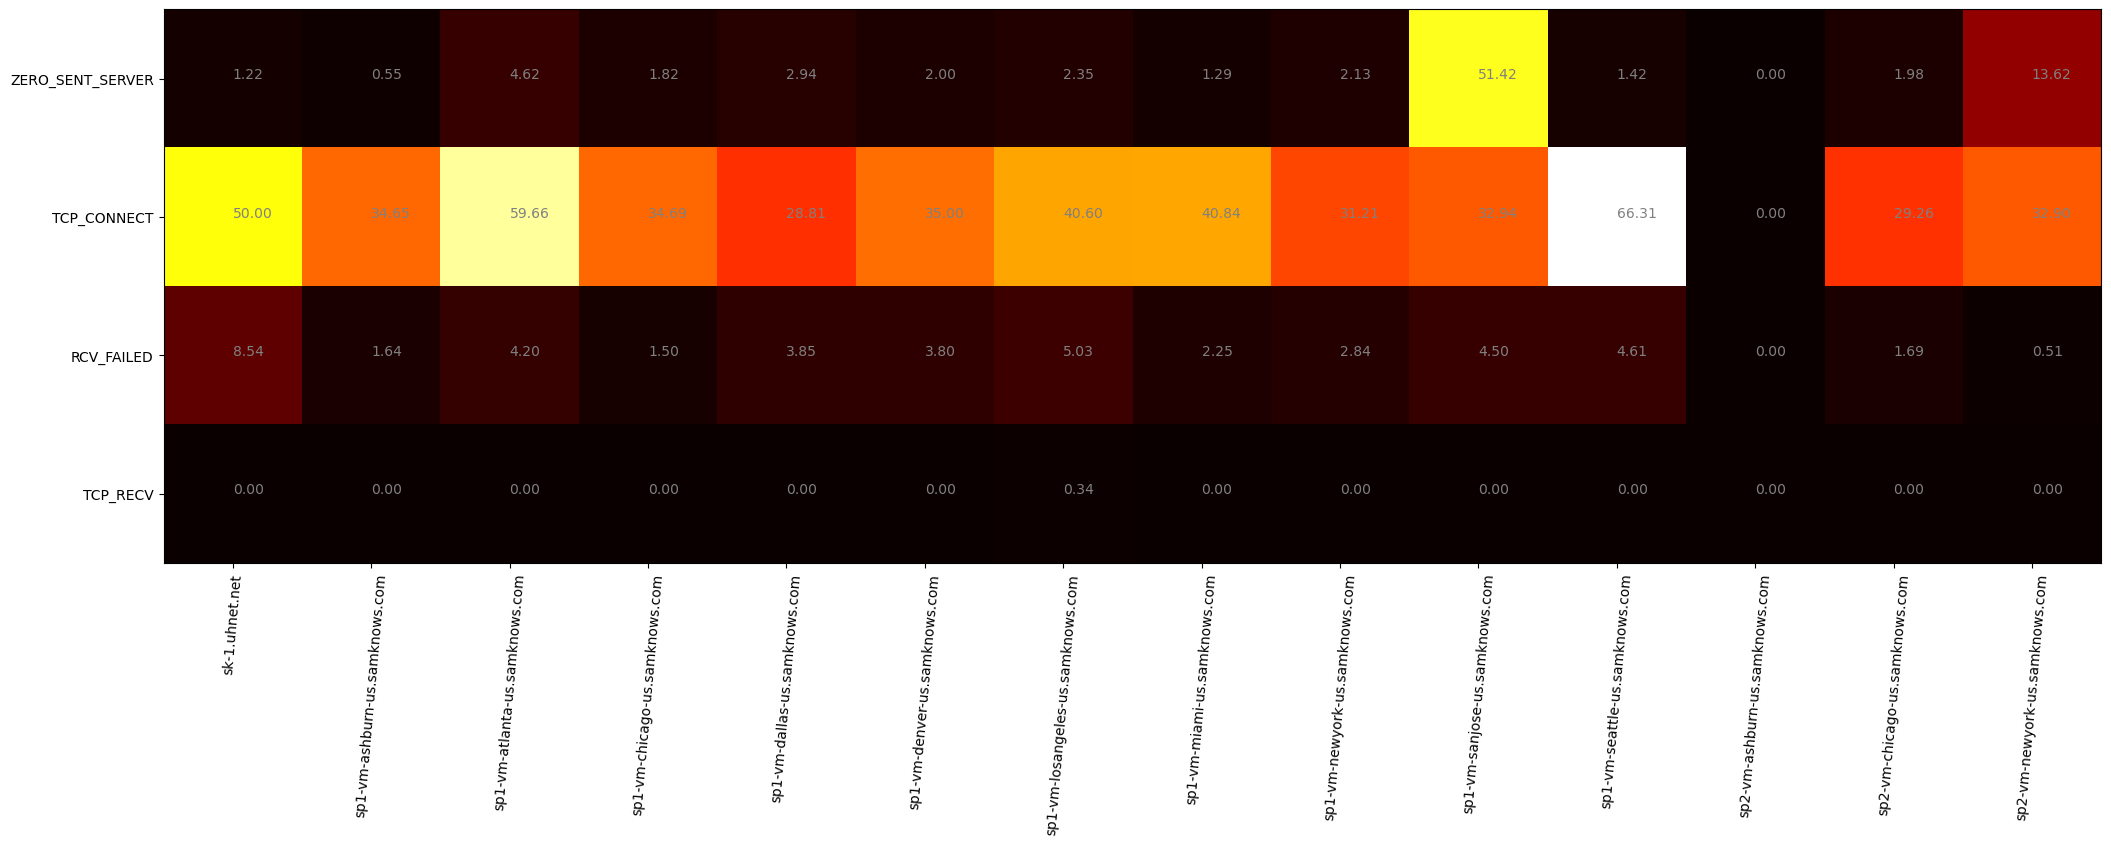

In [22]:
err_types = errors.columns[1:]

targets = errors.to_numpy().transpose()
values = targets[1:].astype(float)
targets = targets[0]

print(len(targets))

fig, ax = plt.subplots(figsize = [25, 10])
ax.imshow(values, cmap="hot")
ax.set_xticks(range(len(targets)), labels=targets, rotation=85)
ax.set_yticks(range(len(err_types)), labels=err_types)

for x in range(len(targets)):
    for y in range(len(err_types)):
        ax.text(x, y, f"{values[y][x]:.2f}", color="gray")

plt.show()

### Joining with pings (avgs)

In [23]:
rtts = ul_ping.group_by("target").agg(pl.col("rtt_avg").mean() / 1_000)

ul_enhanced = up_avgs.join(rtts, how="left", on="target")

ul_enhanced

target,packets_sent_mean,packets_sent_stdev,successes_pct,failures_pct,rtt_avg
str,f64,f64,f64,f64,f64
"""sk-1.uhnet.net""",99.183511,8.999462,99.183511,0.816489,328.618186
"""sp1-vm-ashburn-us.samknows.com""",99.187515,8.977155,99.187515,0.812485,254.512642
"""sp1-vm-atlanta-us.samknows.com""",99.509582,6.98583,99.509582,0.490418,299.22753
"""sp1-vm-chicago-us.samknows.com""",99.143512,9.214987,99.143512,0.856488,285.558082
"""sp1-vm-dallas-us.samknows.com""",99.18698,8.980102,99.18698,0.81302,278.584586
…,…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",98.990189,9.998188,98.990189,1.009811,185.764202
"""sp1-vm-seattle-us.samknows.com""",99.565673,6.576074,99.565673,0.434327,355.396155
"""sp2-vm-ashburn-us.samknows.com""",92.857143,26.226526,92.857143,7.142857,110.064333


In [24]:
rtts = dl_ping.group_by("target").agg(pl.col("rtt_avg").mean() / 1_000)

dw_enhanced = dw_avgs.join(rtts, how="left", on="target")

dw_enhanced

target,packets_received_mean,packets_received_stdev,successes_pct,failures_pct,rtt_avg
str,f64,f64,f64,f64,f64
"""sk-1.uhnet.net""",91.126478,16.719704,99.513164,0.486836,143.599202
"""sp1-vm-ashburn-us.samknows.com""",89.157478,18.943243,99.701347,0.298653,113.549951
"""sp1-vm-atlanta-us.samknows.com""",87.476392,19.428849,99.663918,0.336082,89.129472
"""sp1-vm-chicago-us.samknows.com""",84.214081,22.357806,99.675108,0.324892,109.69154
"""sp1-vm-dallas-us.samknows.com""",88.259337,19.594169,99.710772,0.289228,98.524351
…,…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",90.522035,18.668834,99.103771,0.896229,81.997816
"""sp1-vm-seattle-us.samknows.com""",83.70247,23.118496,99.685675,0.314325,110.711638
"""sp2-vm-ashburn-us.samknows.com""",85.392857,21.615048,100.0,0.0,44.169667


### Joining with pings (time)

In [25]:
ul_ping_hist = ul_ping.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h")).group_by("dtime").agg(pl.col("rtt_avg").mean())
ul_hist = upload_hist.join(ul_ping_hist, how="left", on="dtime")

ul_hist

dtime,packets_sent,mbytes_sec,successes,failures,rtt_avg
datetime[μs],i64,f64,f64,f64,f64
2023-02-01 00:00:00,133000,6.06244,98.884758,1.115242,243813.016393
2023-02-01 01:00:00,279800,5.872537,99.149539,0.850461,243688.513748
2023-02-01 02:00:00,306900,6.212253,99.191984,0.808016,244930.318381
2023-02-01 03:00:00,328700,5.894447,99.215213,0.784787,252465.801685
2023-02-01 04:00:00,337200,5.972213,99.264057,0.735943,262563.26125
…,…,…,…,…,…
2023-02-28 20:00:00,55800,6.148567,99.642857,0.357143,189050.12135
2023-02-28 21:00:00,55300,6.68533,99.281867,0.718133,248595.806414
2023-02-28 22:00:00,58100,6.347422,98.809524,1.190476,260861.574556


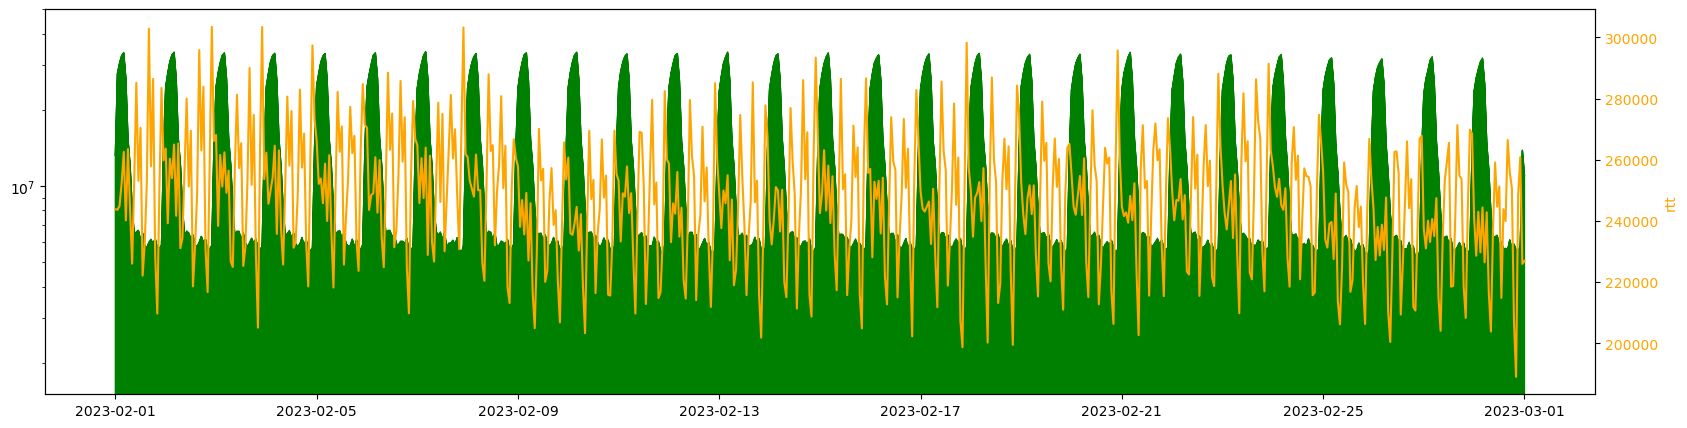

In [26]:
times, packets, mbytes_sec, successes, failures, rtt = ul_hist.cast({"dtime" : pl.String}).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(figsize=[20,5])

stacked = np.array([successes, failures]) * packets

ax2 = ax.twinx()

ax2.errorbar(times, rtt, color="orange")

ax2.set_ylabel("rtt", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

ax.set_ylim(1.5 * 10 ** 6, 5 * 10 ** 7)

ax.set_yscale("log")

ax.stackplot(times, stacked.astype(int), color=["green", "red"])

plt.show()

In [27]:
dw_ping_hist = dl_ping.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h")).group_by("dtime").agg(pl.col("rtt_avg").mean())
dw_hist = dwload_hist.join(dw_ping_hist, how="left", on="dtime")

dw_hist

dtime,packets_sent,mbytes_sec,successes,failures,rtt_avg
datetime[μs],i64,f64,f64,f64,f64
2023-02-01 00:00:00,135300,31.365133,99.558499,0.441501,110318.778198
2023-02-01 01:00:00,280500,30.806859,99.53868,0.46132,103990.551909
2023-02-01 02:00:00,308300,30.913645,99.580103,0.419897,106593.86908
2023-02-01 03:00:00,334700,29.908655,99.494649,0.505351,97589.405055
2023-02-01 04:00:00,341800,30.773184,99.708285,0.291715,112987.076756
…,…,…,…,…,…
2023-02-28 20:00:00,56400,30.877067,99.646643,0.353357,96579.211483
2023-02-28 21:00:00,55700,32.925269,99.464286,0.535714,97468.682243
2023-02-28 22:00:00,58100,29.009264,99.486301,0.513699,113390.907873


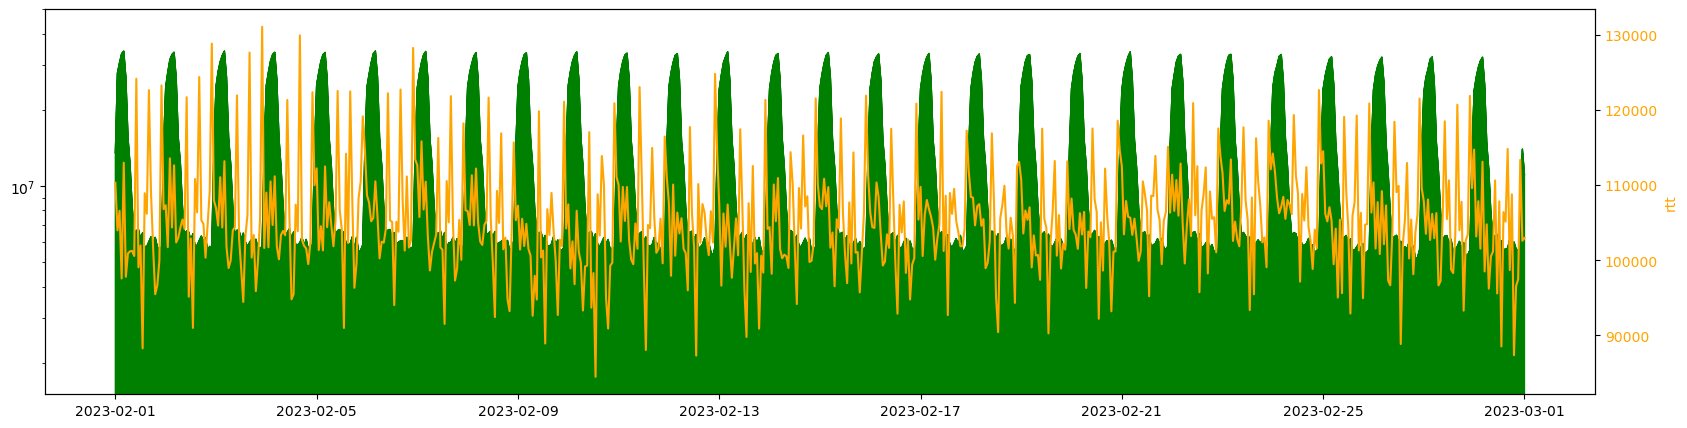

In [28]:
times, packets, mbytes_sec, successes, failures, rtt = dw_hist.cast({"dtime" : pl.String}).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(figsize=[20,5])

stacked = np.array([successes, failures]) * packets

ax2 = ax.twinx()

ax2.errorbar(times, rtt, color="orange")

ax2.set_ylabel("rtt", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

ax.set_ylim(1.5 * 10 ** 6, 5 * 10 ** 7)

ax.set_yscale("log")

ax.stackplot(times, stacked.astype(int), color=["green", "red"])

plt.show()

## Modeling

statistic chosen: rtt

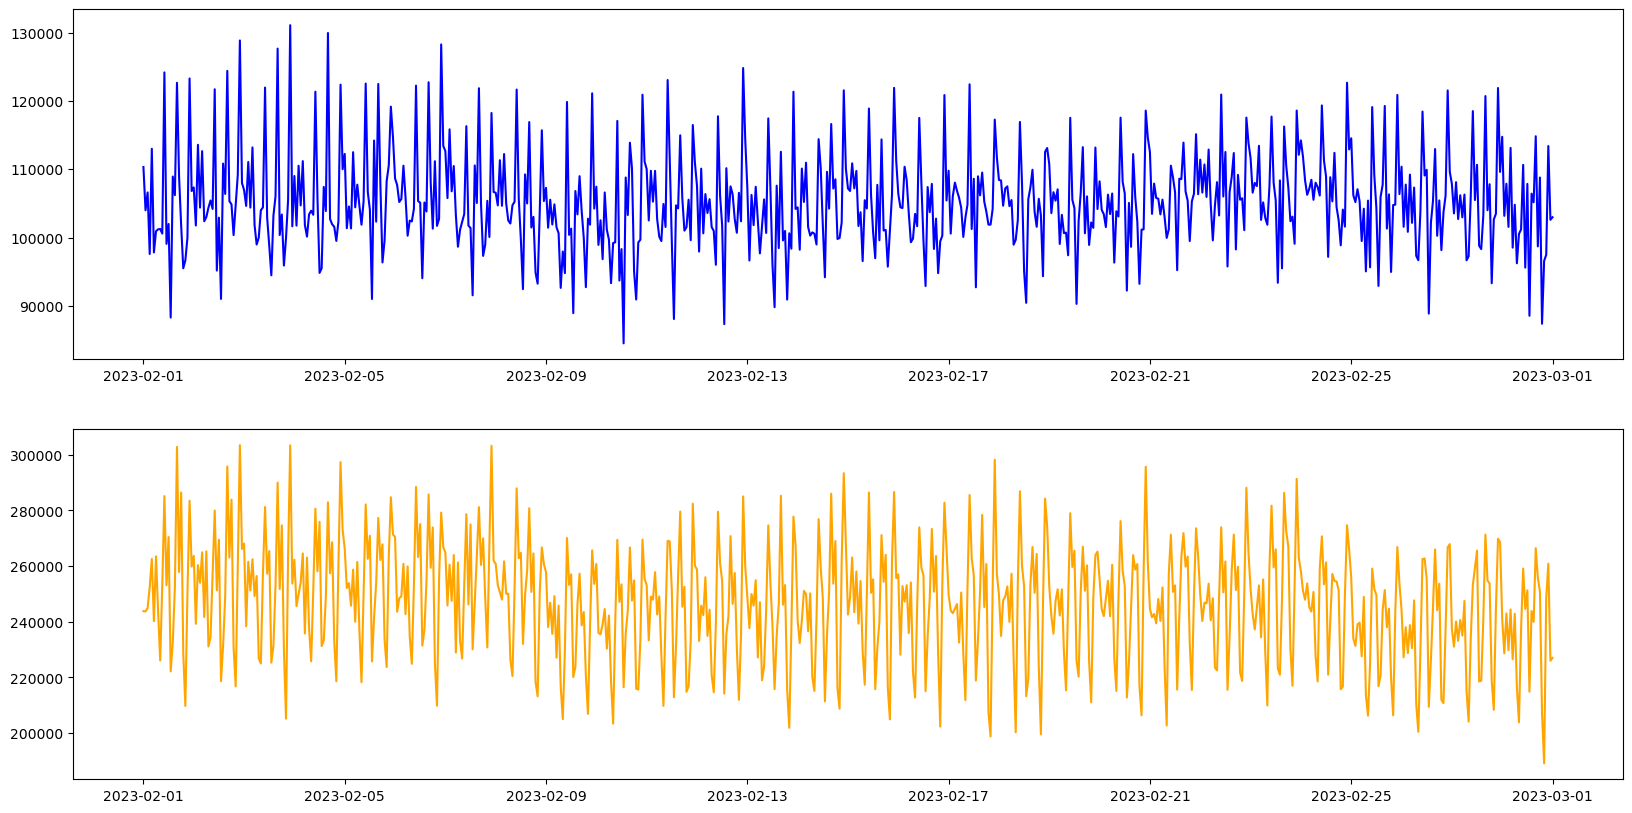

In [29]:
times, dw_rtt, ul_rtt = ul_hist.join(dw_hist.select(["dtime", pl.col("rtt_avg").alias("dw_rtt")]), how="left", on="dtime").cast({"dtime" : pl.String}).select(["dtime", "dw_rtt", pl.col("rtt_avg").alias("ul_rtt")]).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(2, 1,figsize=[20,10])

ax[0].errorbar(times, dw_rtt, color="blue")

ax[1].errorbar(times, ul_rtt, color="orange")

plt.show()

## Evaluation

## Deployment